In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("task-2-Womens-Clothing-E-Commerce-Reviews.csv")

print("Dataset successfully loaded")
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset successfully loaded
Dataset Shape: (23490, 11)

Column Names:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses


In [2]:
print("DATASET INFORMATION")
print("-" * 50)

df.info()

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23490 non-null  int64
 1   Clothing ID              23490 non-null  int64
 2   Age                      23490 non-null  int64
 3   Title                    19680 non-null  str  
 4   Review Text              22645 non-null  str  
 5   Rating                   23490 non-null  int64
 6   Recommended IND          23490 non-null  int64
 7   Positive Feedback Count  23490 non-null  int64
 8   Division Name            23476 non-null  str  
 9   Department Name          23476 non-null  str  
 10  Class Name               23476 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [3]:
audit_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Total Values": len(df),
    "Non-Null Values": df.notnull().sum(),
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique(dropna=True)
})

audit_report

,Data Type,Total Values,Non-Null Values,Missing Values,Missing Percentage,Unique Values
Unnamed: 0,int64,23490,23490,0,0.00,23486
Clothing ID,int64,23490,23490,0,0.00,1206
Age,int64,23490,23490,0,0.00,77
Title,str,23490,19680,3810,16.22,13993
Review Text,str,23490,22645,845,3.60,22634
Rating,int64,23490,23490,0,0.00,5
Recommended IND,int64,23490,23490,0,0.00,2
Positive Feedback Count,int64,23490,23490,0,0.00,82
Division Name,str,23490,23476,14,0.06,3
Department Name,str,23490,23476,14,0.06,6


In [4]:
index_like_columns = []

for column in df.columns:
    column_name = str(column).strip().lower()

    is_unnamed = column_name.startswith("unnamed")

    expected_sequence = np.arange(len(df))
    is_sequential = (
        df[column].notna().all()
        and df[column].nunique() == len(df)
        and np.array_equal(df[column].to_numpy(), expected_sequence)
    )

    if is_unnamed or is_sequential:
        index_like_columns.append(column)

print("Possible irrelevant index columns:", index_like_columns)

Possible irrelevant index columns: ['Unnamed: 0']


In [5]:
duplicates_with_index = df.duplicated().sum()

print("Duplicate rows including index column:",
      duplicates_with_index)

Duplicate rows including index column: 4


In [6]:
duplicate_check_columns = [
    column for column in df.columns
    if column not in index_like_columns
]

duplicate_mask = df.duplicated(
    subset=duplicate_check_columns,
    keep=False
)

duplicate_extra_rows = df.duplicated(
    subset=duplicate_check_columns,
    keep="first"
).sum()

print("Columns used for duplicate detection:")
print(duplicate_check_columns)

print("\nTotal rows present in duplicate groups:",
      duplicate_mask.sum())

print("Extra duplicate rows that can be removed:",
      duplicate_extra_rows)

Columns used for duplicate detection:
['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Total rows present in duplicate groups: 49
Extra duplicate rows that can be removed: 25


In [7]:
duplicate_records = (
    df.loc[duplicate_mask]
      .sort_values(by=duplicate_check_columns, na_position="last")
)

print("Duplicate records shape:", duplicate_records.shape)

duplicate_records.head(10)

Duplicate records shape: (49, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
9675,9671,828,46,NaN,NaN,5,1,0,General Petite,Tops,Blouses
18751,18747,828,46,NaN,NaN,5,1,0,General Petite,Tops,Blouses
2945,2941,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses
4854,4850,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses
4870,4866,834,70,NaN,NaN,5,1,0,General Petite,Tops,Blouses
9310,9306,834,70,NaN,NaN,5,1,0,General Petite,Tops,Blouses
13240,13236,850,37,NaN,NaN,5,1,0,General,Tops,Blouses
17260,17256,850,37,NaN,NaN,5,1,0,General,Tops,Blouses
5540,5536,861,34,NaN,NaN,5,1,0,General,Tops,Knits
5675,5671,861,34,NaN,NaN,5,1,0,General,Tops,Knits


In [8]:
critical_columns = [
    "Clothing ID",
    "Age",
    "Title",
    "Review Text",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Division Name",
    "Department Name",
    "Class Name"
]

print("Critical columns:", critical_columns)

Critical columns: ['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [19]:
def detect_irrelevant_columns(data, critical_columns):

    detection_log = []
    safe_removal_columns = []
    manual_review_columns = []

    for column in data.columns:
        column_name = str(column).strip().lower()

        is_unnamed = column_name.startswith("unnamed")

        is_sequential = False

        if pd.api.types.is_numeric_dtype(data[column]):
            expected_sequence = np.arange(len(data))

            is_sequential = (
                data[column].notna().all()
                and data[column].nunique() == len(data)
                and np.array_equal(
                    data[column].to_numpy(),
                    expected_sequence
                )
            )

        if is_unnamed or is_sequential:
            if column not in critical_columns:
                safe_removal_columns.append(column)

                detection_log.append({
                    "Column": column,
                    "Detection Type": "Index-like column",
                    "Reason": "Contains row numbers instead of business information",
                    "Decision": "Safe to remove"
                })
            else:
                manual_review_columns.append(column)

                detection_log.append({
                    "Column": column,
                    "Detection Type": "Index-like but critical",
                    "Reason": "Column is marked as critical",
                    "Decision": "Retain for safety"
                })

    for column in data.columns:
        if data[column].isna().all():
            if column not in critical_columns:
                safe_removal_columns.append(column)

                detection_log.append({
                    "Column": column,
                    "Detection Type": "Completely empty",
                    "Reason": "All values are missing",
                    "Decision": "Safe to remove"
                })
            else:
                manual_review_columns.append(column)

                detection_log.append({
                    "Column": column,
                    "Detection Type": "Empty critical column",
                    "Reason": "All values missing, but column is critical",
                    "Decision": "Manual review required"
                })

    for column in data.columns:
        if data[column].nunique(dropna=False) <= 1:
            if column not in critical_columns:
                safe_removal_columns.append(column)

                detection_log.append({
                    "Column": column,
                    "Detection Type": "Constant column",
                    "Reason": "Contains the same value in every row",
                    "Decision": "Safe to remove"
                })
            else:
                manual_review_columns.append(column)

                detection_log.append({
                    "Column": column,
                    "Detection Type": "Constant critical column",
                    "Reason": "No variation, but column is critical",
                    "Decision": "Manual review required"
                })

    columns = list(data.columns)

    for current_position in range(len(columns)):
        current_column = columns[current_position]

        for previous_position in range(current_position):
            previous_column = columns[previous_position]

            if data[current_column].equals(data[previous_column]):
                if current_column not in critical_columns:
                    safe_removal_columns.append(current_column)

                    detection_log.append({
                        "Column": current_column,
                        "Detection Type": "Duplicate column",
                        "Reason": f"Exact copy of '{previous_column}'",
                        "Decision": "Safe to remove"
                    })
                else:
                    manual_review_columns.append(current_column)

                    detection_log.append({
                        "Column": current_column,
                        "Detection Type": "Duplicate critical column",
                        "Reason": f"Exact copy of '{previous_column}'",
                        "Decision": "Manual review required"
                    })

                break

    safe_removal_columns = list(
        dict.fromkeys(safe_removal_columns)
    )

    manual_review_columns = list(
        dict.fromkeys(manual_review_columns)
    )

    detection_report = pd.DataFrame(detection_log)

    return (
        detection_report,
        safe_removal_columns,
        manual_review_columns
    )
(
    irrelevant_column_report,
    safe_removal_columns,
    manual_review_columns
) = detect_irrelevant_columns(
    df,
    critical_columns
)

print("Safe removal columns:")
print(safe_removal_columns)

print("\nManual review columns:")
print(manual_review_columns)

print("\nDetection report:")
irrelevant_column_report

Safe removal columns:
['Unnamed: 0']

Manual review columns:
[]

Detection report:


,Column,Detection Type,Reason,Decision
0,Unnamed: 0,Index-like column,Contains row numbers instead of business infor...,Safe to remove


In [20]:
critical_columns_at_risk = [
    column for column in safe_removal_columns
    if column in critical_columns
]

if len(critical_columns_at_risk) == 0:
    print("Validation Passed:")
    print("No critical column is marked for automatic removal.")
else:
    print("Validation Failed!")
    print("Critical columns at risk:", critical_columns_at_risk)

Validation Passed:
No critical column is marked for automatic removal.


In [21]:
def detect_duplicate_rows(data, ignored_columns=None):

    if ignored_columns is None:
        ignored_columns = []

    comparison_columns = [
        column for column in data.columns
        if column not in ignored_columns
    ]

    all_duplicate_mask = data.duplicated(
        subset=comparison_columns,
        keep=False
    )

    removable_duplicate_mask = data.duplicated(
        subset=comparison_columns,
        keep="first"
    )

    all_duplicate_records = data.loc[
        all_duplicate_mask
    ].copy()

    removed_rows_backup = data.loc[
        removable_duplicate_mask
    ].copy()

    removed_rows_backup.insert(
        0,
        "Original DataFrame Index",
        removed_rows_backup.index
    )

    removed_rows_backup["Removal Reason"] = (
        "Exact duplicate of an earlier record"
    )

    duplicate_summary = {
        "Comparison Columns": comparison_columns,
        "Total Duplicate Group Rows": int(
            all_duplicate_mask.sum()
        ),
        "Extra Duplicate Rows": int(
            removable_duplicate_mask.sum()
        ),
        "Original Rows Preserved": int(
            all_duplicate_mask.sum()
            - removable_duplicate_mask.sum()
        )
    }

    return {
        "all_duplicate_records": all_duplicate_records,
        "removed_rows_backup": removed_rows_backup,
        "removable_mask": removable_duplicate_mask,
        "all_duplicate_mask": all_duplicate_mask,
        "summary": duplicate_summary
    }
duplicate_result = detect_duplicate_rows(
    data=df,
    ignored_columns=safe_removal_columns
)

duplicate_summary = duplicate_result["summary"]
all_duplicate_records = duplicate_result[
    "all_duplicate_records"
]
removed_rows_backup = duplicate_result[
    "removed_rows_backup"
]
removable_duplicate_mask = duplicate_result[
    "removable_mask"
]

print("DUPLICATE DETECTION SUMMARY")
print("-" * 50)

for key, value in duplicate_summary.items():
    print(f"{key}: {value}")

DUPLICATE DETECTION SUMMARY
--------------------------------------------------
Comparison Columns: ['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']
Total Duplicate Group Rows: 49
Extra Duplicate Rows: 25
Original Rows Preserved: 24


In [22]:
print(
    "All duplicate records shape:",
    all_duplicate_records.shape
)

all_duplicate_records.head(10)

All duplicate records shape: (49, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
5,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
6,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
11,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses
12,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses
302,298,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
497,493,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses
1008,1004,1094,30,NaN,NaN,5,1,0,General,Dresses,Dresses


In [23]:
print(
    "Removed rows backup shape:",
    removed_rows_backup.shape
)

removed_rows_backup.head(10)

Removed rows backup shape: (25, 13)


,Original DataFrame Index,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Removal Reason
3,3,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Exact duplicate of an earlier record
4,4,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Exact duplicate of an earlier record
6,6,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Exact duplicate of an earlier record
12,12,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses,Exact duplicate of an earlier record
497,497,493,1104,39,NaN,NaN,5,1,0,General,Dresses,Dresses,Exact duplicate of an earlier record
2963,2963,2959,1094,30,NaN,NaN,5,1,0,General,Dresses,Dresses,Exact duplicate of an earlier record
4854,4854,4850,829,66,NaN,NaN,5,1,0,General Petite,Tops,Blouses,Exact duplicate of an earlier record
5675,5675,5671,861,34,NaN,NaN,5,1,0,General,Tops,Knits,Exact duplicate of an earlier record
5780,5780,5776,868,61,NaN,NaN,5,1,0,General,Tops,Knits,Exact duplicate of an earlier record
9310,9310,9306,834,70,NaN,NaN,5,1,0,General Petite,Tops,Blouses,Exact duplicate of an earlier record


In [24]:
comparison_columns = duplicate_summary[
    "Comparison Columns"
]

remaining_after_duplicates = df.loc[
    ~removable_duplicate_mask
]

duplicates_remaining = remaining_after_duplicates.duplicated(
    subset=comparison_columns
).sum()

print(
    "Duplicates remaining after proposed removal:",
    duplicates_remaining
)

Duplicates remaining after proposed removal: 0


In [25]:
def custom_data_cleaning_pipeline(data, critical_columns):

    working_data = data.copy(deep=True)

    original_rows = working_data.shape[0]
    original_columns = working_data.shape[1]

    (
        column_detection_report,
        safe_removal_columns,
        manual_review_columns
    ) = detect_irrelevant_columns(
        working_data,
        critical_columns
    )

    critical_columns_at_risk = [
        column for column in safe_removal_columns
        if column in critical_columns
    ]

    if critical_columns_at_risk:
        raise ValueError(
            "Pipeline stopped! Critical columns marked "
            f"for removal: {critical_columns_at_risk}"
        )

    if safe_removal_columns:
        removed_columns_backup = working_data[
            safe_removal_columns
        ].copy()
    else:
        removed_columns_backup = pd.DataFrame(
            index=working_data.index
        )

    duplicate_result = detect_duplicate_rows(
        working_data,
        ignored_columns=safe_removal_columns
    )

    removable_duplicate_mask = duplicate_result[
        "removable_mask"
    ]

    removed_rows_backup = duplicate_result[
        "removed_rows_backup"
    ]

    duplicate_summary = duplicate_result["summary"]

    cleaned_data = working_data.loc[
        ~removable_duplicate_mask
    ].copy()

    cleaned_data = cleaned_data.drop(
        columns=safe_removal_columns,
        errors="ignore"
    )

    cleaned_data = cleaned_data.reset_index(drop=True)

    remaining_duplicates = cleaned_data.duplicated(
        subset=list(cleaned_data.columns)
    ).sum()

    missing_critical_columns = [
        column for column in critical_columns
        if column not in cleaned_data.columns
    ]

    critical_columns_preserved = (
        len(missing_critical_columns) == 0
    )

    cleaning_log = pd.DataFrame([
        {
            "Metric": "Original rows",
            "Value": original_rows
        },
        {
            "Metric": "Original columns",
            "Value": original_columns
        },
        {
            "Metric": "Rows in duplicate groups",
            "Value": duplicate_summary[
                "Total Duplicate Group Rows"
            ]
        },
        {
            "Metric": "Extra duplicate rows removed",
            "Value": duplicate_summary[
                "Extra Duplicate Rows"
            ]
        },
        {
            "Metric": "Irrelevant columns removed",
            "Value": len(safe_removal_columns)
        },
        {
            "Metric": "Removed column names",
            "Value": (
                ", ".join(safe_removal_columns)
                if safe_removal_columns
                else "None"
            )
        },
        {
            "Metric": "Manual-review columns",
            "Value": (
                ", ".join(manual_review_columns)
                if manual_review_columns
                else "None"
            )
        },
        {
            "Metric": "Final rows",
            "Value": cleaned_data.shape[0]
        },
        {
            "Metric": "Final columns",
            "Value": cleaned_data.shape[1]
        },
        {
            "Metric": "Duplicates remaining",
            "Value": int(remaining_duplicates)
        },
        {
            "Metric": "Critical columns preserved",
            "Value": critical_columns_preserved
        },
        {
            "Metric": "Missing critical columns",
            "Value": (
                ", ".join(missing_critical_columns)
                if missing_critical_columns
                else "None"
            )
        }
    ])

    return {
        "cleaned_data": cleaned_data,
        "removed_rows_backup": removed_rows_backup,
        "removed_columns_backup": removed_columns_backup,
        "cleaning_log": cleaning_log,
        "column_detection_report": column_detection_report,
        "safe_removal_columns": safe_removal_columns,
        "manual_review_columns": manual_review_columns
    }
pipeline_result = custom_data_cleaning_pipeline(
    data=df,
    critical_columns=critical_columns
)

df_cleaned = pipeline_result["cleaned_data"]

removed_rows_backup = pipeline_result[
    "removed_rows_backup"
]

removed_columns_backup = pipeline_result[
    "removed_columns_backup"
]

cleaning_log = pipeline_result["cleaning_log"]

column_detection_report = pipeline_result[
    "column_detection_report"
]

print("Custom data-cleaning pipeline executed successfully.")

Custom data-cleaning pipeline executed successfully.


In [26]:
cleaning_log

,Metric,Value
0,Original rows,23490
1,Original columns,11
2,Rows in duplicate groups,49
3,Extra duplicate rows removed,25
4,Irrelevant columns removed,1
5,Removed column names,Unnamed: 0
6,Manual-review columns,None
7,Final rows,23465
8,Final columns,10
9,Duplicates remaining,0


In [27]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_cleaned.shape)

print("\nCleaned dataset columns:")
print(df_cleaned.columns.tolist())

df_cleaned.head()

Original dataset shape: (23490, 11)
Cleaned dataset shape: (23465, 10)

Cleaned dataset columns:
['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [28]:
print("Original df shape:", df.shape)
print("Cleaned df shape:", df_cleaned.shape)

print(
    "'Unnamed: 0' in original df:",
    "Unnamed: 0" in df.columns
)

print(
    "'Unnamed: 0' in cleaned df:",
    "Unnamed: 0" in df_cleaned.columns
)

Original df shape: (23490, 11)
Cleaned df shape: (23465, 10)
'Unnamed: 0' in original df: True
'Unnamed: 0' in cleaned df: False


In [29]:
expected_cleaned_data = (
    df.drop(
        columns=safe_removal_columns,
        errors="ignore"
    )
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

print(
    "Expected cleaned shape:",
    expected_cleaned_data.shape
)

print(
    "Pipeline cleaned shape:",
    df_cleaned.shape
)

Expected cleaned shape: (23465, 10)
Pipeline cleaned shape: (23465, 10)


In [30]:
content_matches_expected = df_cleaned.equals(
    expected_cleaned_data
)

print(
    "Pipeline output matches expected data:",
    content_matches_expected
)

Pipeline output matches expected data: True


In [31]:
original_row_count = len(df)
removed_duplicate_count = len(removed_rows_backup)
expected_final_row_count = (
    original_row_count - removed_duplicate_count
)
actual_final_row_count = len(df_cleaned)

row_count_valid = (
    expected_final_row_count == actual_final_row_count
)

print("Original rows:", original_row_count)
print("Removed duplicate rows:", removed_duplicate_count)
print("Expected final rows:", expected_final_row_count)
print("Actual final rows:", actual_final_row_count)
print("Row count validation:", row_count_valid)

Original rows: 23490
Removed duplicate rows: 25
Expected final rows: 23465
Actual final rows: 23465
Row count validation: True


In [32]:
missing_critical_columns = [
    column for column in critical_columns
    if column not in df_cleaned.columns
]

critical_columns_valid = (
    len(missing_critical_columns) == 0
)

print(
    "Critical columns preserved:",
    critical_columns_valid
)

print(
    "Missing critical columns:",
    missing_critical_columns
)

Critical columns preserved: True
Missing critical columns: []


In [33]:
data_type_comparison = pd.DataFrame({
    "Original Data Type": [
        str(df[column].dtype)
        for column in critical_columns
    ],
    "Cleaned Data Type": [
        str(df_cleaned[column].dtype)
        for column in critical_columns
    ]
}, index=critical_columns)

data_type_comparison["Data Type Preserved"] = (
    data_type_comparison["Original Data Type"]
    == data_type_comparison["Cleaned Data Type"]
)

data_type_comparison

,Original Data Type,Cleaned Data Type,Data Type Preserved
Clothing ID,int64,int64,True
Age,int64,int64,True
Title,str,str,True
Review Text,str,str,True
Rating,int64,int64,True
Recommended IND,int64,int64,True
Positive Feedback Count,int64,int64,True
Division Name,str,str,True
Department Name,str,str,True
Class Name,str,str,True


In [34]:
data_types_valid = (
    data_type_comparison[
        "Data Type Preserved"
    ].all()
)

print("All data types preserved:", data_types_valid)

All data types preserved: True


In [35]:
unique_value_validation = pd.DataFrame({
    "Original Unique Values": [
        df[column].nunique(dropna=False)
        for column in critical_columns
    ],
    "Cleaned Unique Values": [
        df_cleaned[column].nunique(dropna=False)
        for column in critical_columns
    ]
}, index=critical_columns)

unique_value_validation[
    "Unique Information Preserved"
] = (
    unique_value_validation[
        "Original Unique Values"
    ]
    == unique_value_validation[
        "Cleaned Unique Values"
    ]
)

unique_value_validation

,Original Unique Values,Cleaned Unique Values,Unique Information Preserved
Clothing ID,1206,1206,True
Age,77,77,True
Title,13994,13994,True
Review Text,22635,22635,True
Rating,5,5,True
Recommended IND,2,2,True
Positive Feedback Count,82,82,True
Division Name,4,4,True
Department Name,7,7,True
Class Name,21,21,True


In [36]:
unique_information_valid = (
    unique_value_validation[
        "Unique Information Preserved"
    ].all()
)

print(
    "All unique information preserved:",
    unique_information_valid
)

All unique information preserved: True


In [37]:
duplicates_remaining = df_cleaned.duplicated().sum()

irrelevant_columns_remaining = [
    column for column in safe_removal_columns
    if column in df_cleaned.columns
]

print(
    "Duplicate rows remaining:",
    duplicates_remaining
)

print(
    "Irrelevant columns remaining:",
    irrelevant_columns_remaining
)

Duplicate rows remaining: 0
Irrelevant columns remaining: []


In [38]:
validation_report = pd.DataFrame([
    {
        "Validation Check": "Row count is correct",
        "Result": row_count_valid
    },
    {
        "Validation Check": "Output matches expected data",
        "Result": content_matches_expected
    },
    {
        "Validation Check": "Critical columns preserved",
        "Result": critical_columns_valid
    },
    {
        "Validation Check": "Data types preserved",
        "Result": data_types_valid
    },
    {
        "Validation Check": "Unique information preserved",
        "Result": unique_information_valid
    },
    {
        "Validation Check": "No duplicate rows remain",
        "Result": duplicates_remaining == 0
    },
    {
        "Validation Check": "No irrelevant columns remain",
        "Result": len(irrelevant_columns_remaining) == 0
    }
])

validation_report

,Validation Check,Result
0,Row count is correct,True
1,Output matches expected data,True
2,Critical columns preserved,True
3,Data types preserved,True
4,Unique information preserved,True
5,No duplicate rows remain,True
6,No irrelevant columns remain,True


In [39]:
all_validations_passed = validation_report[
    "Result"
].all()

if all_validations_passed:
    print("VALIDATION PASSED")
    print(
        "Cleaning completed without loss of "
        "critical information."
    )
else:
    print("VALIDATION FAILED")
    print(
        "Review the failed checks before saving files."
    )

VALIDATION PASSED
Cleaning completed without loss of critical information.


In [40]:
output_folder = "task_2_womens_clothing_cleaning_output"

os.makedirs(
    output_folder,
    exist_ok=True
)

print("Output folder created:", output_folder)

Output folder created: task_2_womens_clothing_cleaning_output


In [41]:
removed_columns_backup_to_save = (
    removed_columns_backup.copy()
)

if "Original DataFrame Index" not in (
    removed_columns_backup_to_save.columns
):
    removed_columns_backup_to_save.insert(
        0,
        "Original DataFrame Index",
        removed_columns_backup_to_save.index
    )

removed_columns_backup_to_save.head()

,Original DataFrame Index,Unnamed: 0
0,0,0
1,1,1
2,2,2
3,3,2
4,4,2


In [42]:
df_cleaned.to_csv(
    os.path.join(
        output_folder,
        "womens_clothing_cleaned.csv"
    ),
    index=False
)

removed_rows_backup.to_csv(
    os.path.join(
        output_folder,
        "removed_duplicate_rows_backup.csv"
    ),
    index=False
)

removed_columns_backup_to_save.to_csv(
    os.path.join(
        output_folder,
        "removed_columns_backup.csv"
    ),
    index=False
)

cleaning_log.to_csv(
    os.path.join(
        output_folder,
        "cleaning_summary_log.csv"
    ),
    index=False
)

column_detection_report.to_csv(
    os.path.join(
        output_folder,
        "column_detection_report.csv"
    ),
    index=False
)

validation_report.to_csv(
    os.path.join(
        output_folder,
        "validation_report.csv"
    ),
    index=False
)

data_type_comparison.to_csv(
    os.path.join(
        output_folder,
        "data_type_validation.csv"
    ),
    index=True,
    index_label="Column"
)

unique_value_validation.to_csv(
    os.path.join(
        output_folder,
        "unique_information_validation.csv"
    ),
    index=True,
    index_label="Column"
)

print("All project files saved successfully.")

All project files saved successfully.


In [43]:
saved_files = sorted(
    os.listdir(output_folder)
)

print("SAVED PROJECT FILES")
print("-" * 50)

for file_number, file_name in enumerate(
    saved_files,
    start=1
):
    file_path = os.path.join(
        output_folder,
        file_name
    )

    file_size_kb = os.path.getsize(
        file_path
    ) / 1024

    print(
        f"{file_number}. {file_name} "
        f"({file_size_kb:.2f} KB)"
    )

SAVED PROJECT FILES
--------------------------------------------------
1. cleaning_before_after_comparison.png (131.32 KB)
2. cleaning_summary_log.csv (0.33 KB)
3. column_detection_report.csv (0.13 KB)
4. data_type_validation.csv (0.34 KB)
5. removed_columns_backup.csv (276.53 KB)
6. removed_duplicate_rows_backup.csv (3.87 KB)
7. unique_information_validation.csv (0.32 KB)
8. validation_report.csv (0.24 KB)
9. womens_clothing_cleaned.csv (8179.73 KB)


In [44]:
cleaned_file_path = os.path.join(
    output_folder,
    "womens_clothing_cleaned.csv"
)

saved_cleaned_data = pd.read_csv(
    cleaned_file_path
)

print(
    "Saved cleaned dataset shape:",
    saved_cleaned_data.shape
)

print(
    "Duplicate rows in saved file:",
    saved_cleaned_data.duplicated().sum()
)

print(
    "'Unnamed: 0' present:",
    "Unnamed: 0" in saved_cleaned_data.columns
)

print(
    "All critical columns present:",
    all(
        column in saved_cleaned_data.columns
        for column in critical_columns
    )
)

Saved cleaned dataset shape: (23465, 10)
Duplicate rows in saved file: 0
'Unnamed: 0' present: False
All critical columns present: True


In [45]:
saved_duplicate_backup = pd.read_csv(
    os.path.join(
        output_folder,
        "removed_duplicate_rows_backup.csv"
    )
)

saved_column_backup = pd.read_csv(
    os.path.join(
        output_folder,
        "removed_columns_backup.csv"
    )
)

print(
    "Saved duplicate backup shape:",
    saved_duplicate_backup.shape
)

print(
    "Saved column backup shape:",
    saved_column_backup.shape
)

Saved duplicate backup shape: (25, 13)
Saved column backup shape: (23490, 2)


In [46]:
comparison_columns = [
    column for column in df.columns
    if column not in safe_removal_columns
]

duplicates_before = df.duplicated(
    subset=comparison_columns,
    keep="first"
).sum()

before_after_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        duplicates_before
    ],
    "After Cleaning": [
        df_cleaned.shape[0],
        df_cleaned.shape[1],
        df_cleaned.duplicated().sum()
    ]
})

before_after_summary

,Metric,Before Cleaning,After Cleaning
0,Total Rows,23490,23465
1,Total Columns,11,10
2,Duplicate Rows,25,0


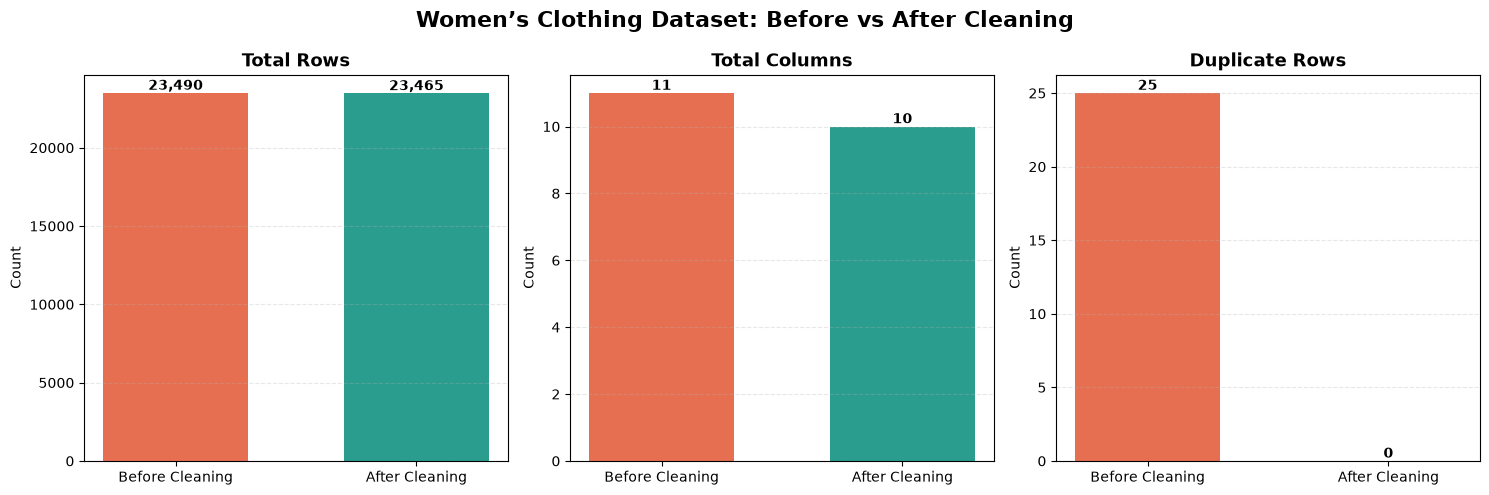

Chart saved at: task_2_womens_clothing_cleaning_output\cleaning_before_after_comparison.png


In [47]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

chart_details = [
    {
        "title": "Total Rows",
        "before": df.shape[0],
        "after": df_cleaned.shape[0]
    },
    {
        "title": "Total Columns",
        "before": df.shape[1],
        "after": df_cleaned.shape[1]
    },
    {
        "title": "Duplicate Rows",
        "before": duplicates_before,
        "after": df_cleaned.duplicated().sum()
    }
]

for axis, details in zip(axes, chart_details):

    values = [
        details["before"],
        details["after"]
    ]

    bars = axis.bar(
        ["Before Cleaning", "After Cleaning"],
        values,
        color=["#E76F51", "#2A9D8F"],
        width=0.6
    )

    axis.set_title(
        details["title"],
        fontsize=13,
        fontweight="bold"
    )

    axis.set_ylabel("Count")
    axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    for bar, value in zip(bars, values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:,}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

fig.suptitle(
    "Women’s Clothing Dataset: Before vs After Cleaning",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

chart_path = os.path.join(
    output_folder,
    "cleaning_before_after_comparison.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved at:", chart_path)

In [48]:
duplicate_removal_percentage = (
    len(removed_rows_backup) / len(df)
) * 100

column_removal_percentage = (
    len(safe_removal_columns) / len(df.columns)
) * 100

data_retention_percentage = (
    len(df_cleaned) / len(df)
) * 100

print(
    "Duplicate row removal percentage:",
    f"{duplicate_removal_percentage:.2f}%"
)

print(
    "Column removal percentage:",
    f"{column_removal_percentage:.2f}%"
)

print(
    "Row retention percentage:",
    f"{data_retention_percentage:.2f}%"
)

Duplicate row removal percentage: 0.11%
Column removal percentage: 9.09%
Row retention percentage: 99.89%


In [49]:
print("=" * 60)
print("FINAL DATA-CLEANING PIPELINE STATUS")
print("=" * 60)

print(f"Original shape       : {df.shape}")
print(f"Cleaned shape        : {df_cleaned.shape}")
print(f"Duplicate rows removed: {len(removed_rows_backup)}")
print(f"Columns removed      : {safe_removal_columns}")
print(
    f"Duplicates remaining : "
    f"{df_cleaned.duplicated().sum()}"
)
print(
    f"Critical columns safe: "
    f"{critical_columns_valid}"
)
print(
    f"All validations passed: "
    f"{all_validations_passed}"
)

if all_validations_passed:
    print("\nPROJECT TASK COMPLETED SUCCESSFULLY")
else:
    print("\nPROJECT REQUIRES MANUAL REVIEW")

FINAL DATA-CLEANING PIPELINE STATUS
Original shape       : (23490, 11)
Cleaned shape        : (23465, 10)
Duplicate rows removed: 25
Columns removed      : ['Unnamed: 0']
Duplicates remaining : 0
Critical columns safe: True
All validations passed: True

PROJECT TASK COMPLETED SUCCESSFULLY
